<a href="https://colab.research.google.com/github/joseevitor/reconhecimento_de_texto_OCR_OpenCV/blob/main/VisaoComputacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OCR no Colab

In [79]:
!pip install "numpy<2.0" "opencv-python==4.6.0.66" "pytesseract==0.3.9"
!sudo apt-get install -y tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [80]:
import pytesseract
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

In [81]:
! git clone https://github.com/sthemonica/text-recognize

Cloning into 'text-recognize'...
remote: Enumerating objects: 148, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 148 (delta 3), reused 1 (delta 1), pack-reused 144 (from 1)
Receiving objects: 100% (148/148), 37.21 MiB | 35.31 MiB/s, done.
Resolving deltas: 100% (35/35), done.


In [82]:
pytesseract.__version__

'0.3.9'

In [83]:
cv2.__version__

'4.6.0'

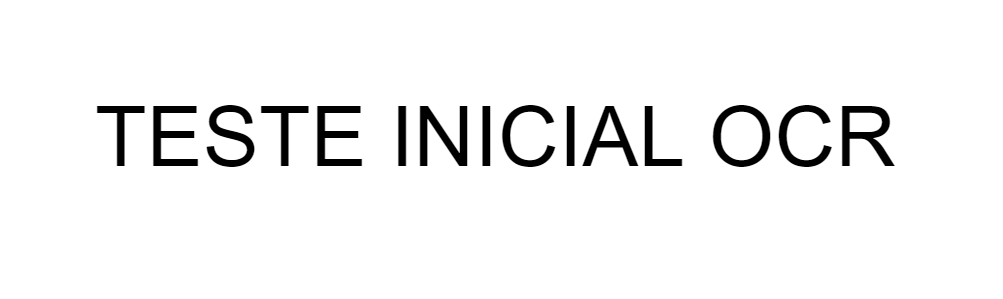

In [84]:
img = cv2.imread("/content/text-recognize/Imagens/Aula1-teste.png")
cv2_imshow(img)

In [85]:
text = pytesseract.image_to_string(img)
print(text)

TESTE INICIAL OCR



Normalmente as bibliotecas interpretam as imagens no formato RGB, que é uma versão reduzida de Red, Green e Blue, as três cores primárias que dão origem as outras cores, mas no OpenCV as entradas R e B são invertidas. SE a intenção for fazer a conexão da biblioteca com qualquer outra biblioteca para exibir a imagem, manipular ou qualquer outro tipo de ação, teria que nesse casofazer a conversão do BGR pro RGB.

# IMGs BGR

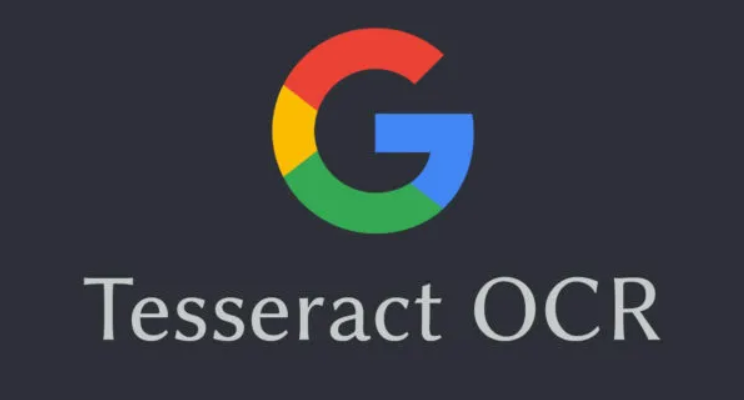

In [86]:
img = cv2.imread("/content/text-recognize/Imagens/Aula1-ocr.png")
cv2_imshow(img)

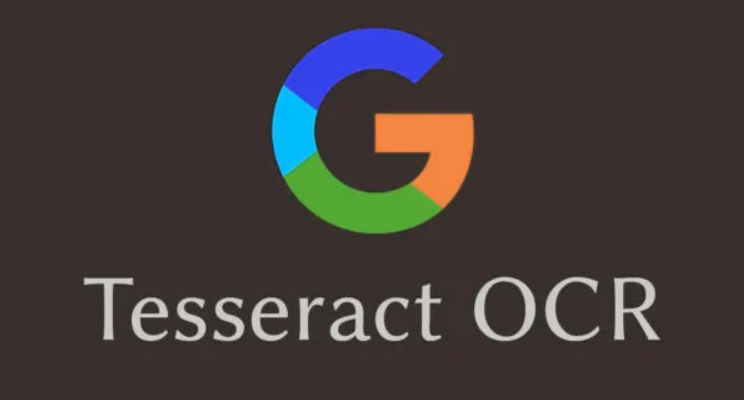

In [87]:
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2_imshow(rgb)

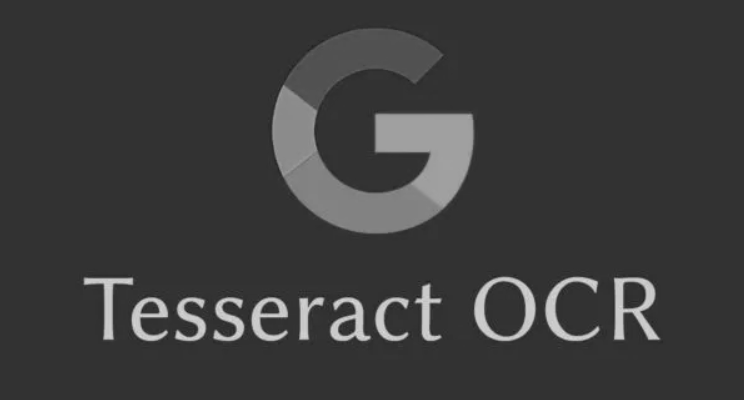

In [88]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
cv2_imshow(gray)

In [89]:
text = pytesseract.image_to_string(rgb)
print(text)

c

Tesseract OCR



In [90]:
text = pytesseract.image_to_string(gray)
print(text)

Se

Tesseract OCR



# Caracteres diferentes

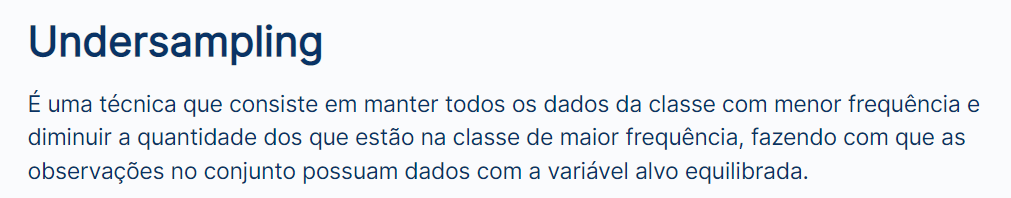

In [91]:
img = cv2.imread("/content/text-recognize/Imagens/Aula2-undersampling.png")
cv2_imshow(img)

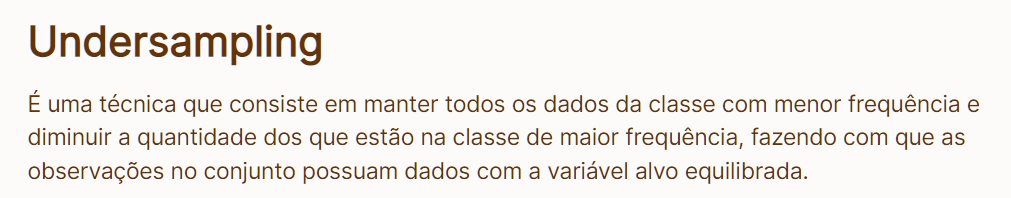

In [92]:
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2_imshow(rgb)


In [93]:
text = pytesseract.image_to_string(rgb)
print(text)

Undersampling

E uma técnica que consiste em manter todos os dados da classe com menor frequéncia e
diminuir a quantidade dos que estdo na classe de maior frequéncia, fazendo com que as
observagées no conjunto possuam dados com a variavel alvo equilibrada.



In [94]:
!tesseract --list-langs

List of available languages (3):
eng
osd
por


Tem que instalar o português

In [95]:
!apt-get install tesseract-ocr-por

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr-por is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [96]:
!tesseract --list-langs


List of available languages (3):
eng
osd
por


In [97]:
text = pytesseract.image_to_string(rgb, lang="por")
print(text)

Undersampling

É uma técnica que consiste em manter todos os dados da classe com menor frequência e
diminuir a quantidade dos que estão na classe de maior frequência, fazendo com que as
observações no conjunto possuam dados com a variável alvo equilibrada.



Como fazer o download de cada idioma, salvando em uma pasta e usando diretamento do Colab

In [98]:
!mkdir tessdata

In [99]:
!wget -O ./tessdata/por.traineddata https://github.com/tesseract-ocr/tessdata/blob/main/por.traineddata?raw=true
!wget -O ./tessdata/eng.traineddata https://github.com/tesseract-ocr/tessdata/blob/main/eng.traineddata?raw=true

--2026-07-13 01:10:42--  https://github.com/tesseract-ocr/tessdata/blob/main/por.traineddata?raw=true
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/tesseract-ocr/tessdata/raw/refs/heads/main/por.traineddata [following]
--2026-07-13 01:10:42--  https://github.com/tesseract-ocr/tessdata/raw/refs/heads/main/por.traineddata
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/tesseract-ocr/tessdata/refs/heads/main/por.traineddata [following]
--2026-07-13 01:10:42--  https://raw.githubusercontent.com/tesseract-ocr/tessdata/refs/heads/main/por.traineddata
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.1

In [100]:
config_tesseract = "--tessdata-dir tessdata"
text = pytesseract.image_to_string(rgb, lang="por", config=config_tesseract)
print(text)

Undersampling

É uma técnica que consiste em manter todos os dados da classe com menor frequência e
diminuir a quantidade dos que estão na classe de maior frequência, fazendo com que as
observações no conjunto possuam dados com a variável alvo equilibrada.



Se eu quiser ver quais são os idiomas disponíveis posso fazer igual um comando no linux


In [101]:
!ls tessdata/

eng.traineddata  por.traineddata


# PSM

Page Segmentation Mode

In [102]:
!tesseract --help-psm

Page segmentation modes:
  0    Orientation and script detection (OSD) only.
  1    Automatic page segmentation with OSD.
  2    Automatic page segmentation, but no OSD, or OCR. (not implemented)
  3    Fully automatic page segmentation, but no OSD. (Default)
  4    Assume a single column of text of variable sizes.
  5    Assume a single uniform block of vertically aligned text.
  6    Assume a single uniform block of text.
  7    Treat the image as a single text line.
  8    Treat the image as a single word.
  9    Treat the image as a single word in a circle.
 10    Treat the image as a single character.
 11    Sparse text. Find as much text as possible in no particular order.
 12    Sparse text with OSD.
 13    Raw line. Treat the image as a single text line,
       bypassing hacks that are Tesseract-specific.


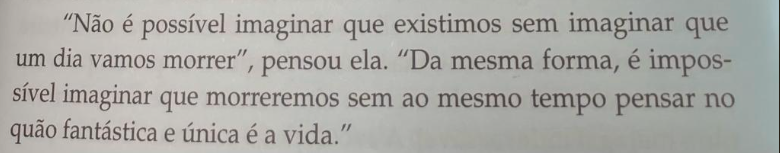

In [103]:
img = cv2.imread("/content/text-recognize/Imagens/Aula2-trecho-livro.png")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2_imshow(rgb)

In [104]:
config_tesseract = "--tessdata-dir tessdata"
text = pytesseract.image_to_string(rgb, lang="por", config=config_tesseract)
print(text)

“Não é possível imaginar que existimos sem imaginar que
um dia vamos morrer”, pensou ela. “Da mesma forma, é impos-
sível imaginar que morreremos sem ao mesmo tempo pensar no
quão fantástica e única é a vida.”



Dá pra tipar o psm utilizado, pra garantir que o OpenCV vai interpretar na maneira "correta", de acordo com as classificações do Page Segmentation Mode.

In [105]:
config_tesseract = "--tessdata-dir tessdata --psm 6"
text = pytesseract.image_to_string(rgb, lang="por", config=config_tesseract)
print(text)

“Não é possível imaginar que existimos sem imaginar que
um dia vamos morrer”, pensou ela. “Da mesma forma, é impos-
sível imaginar que morreremos sem ao mesmo tempo pensar no
quão fantástica e única é a vida.”



In [106]:
config_tesseract = "--tessdata-dir tessdata --psm 7"
text = pytesseract.image_to_string(rgb, lang="por", config=config_tesseract)
print(text)

In [107]:
config_tesseract = "--tessdata-dir tessdata --psm 8"
text = pytesseract.image_to_string(rgb, lang="por", config=config_tesseract)
print(text)

ªfâ%êããããââª%%?ªííÉ:D;Z:Én:gíríãrgâgíie::ugfâ|



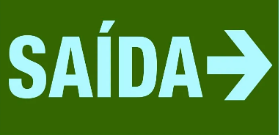

SAÍDAS



In [108]:
img = cv2.imread("/content/text-recognize/Imagens/Aula2-Saida.png")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
config_tesseract = "--tessdata-dir tessdata --psm 7"
text = pytesseract.image_to_string(rgb, lang="por", config=config_tesseract)
cv2_imshow(rgb)
print(text)

ESTE MODO É BASTANTE USADO PARA PLACAS DE CARRO

# Biblioteca Pillow

In [109]:
from PIL import Image
import matplotlib.pyplot as plt

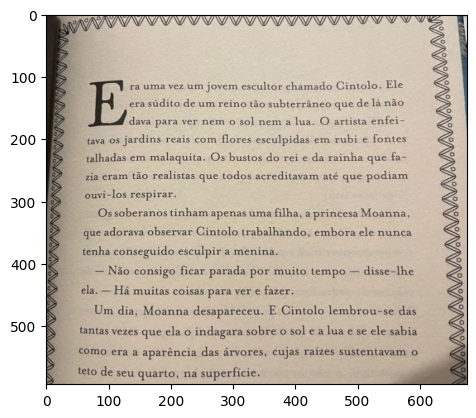

In [110]:
img = Image.open("/content/text-recognize/Imagens/Aula2-livro.png")
plt.imshow(img);

In [111]:
print(pytesseract.image_to_osd(img))

Page number: 0
Orientation in degrees: 0
Rotate: 0
Orientation confidence: 0.93
Script: Latin
Script confidence: 2.46



OFF TOPIC, ABAIXO SEGUE UM EXEMPLO DE O QUE FAZER SE EU QUISER CARREGAR, GIRAR 45 GRAUS E DEPOIS ABRIR UMA IMAGEM

In [112]:
from PIL import Image
with Image.open("image.jpg") as im:
  im.rotate(45).show()

# CERTAMENTE AQUI N VAI RODAR PQ É MAIS UMA CURIOSIDADE

FileNotFoundError: [Errno 2] No such file or directory: 'image.jpg'

CONTINUANDO...

# Selecionando textos

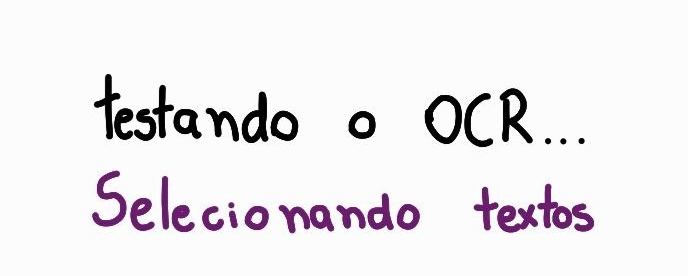

In [113]:
img = cv2.imread("/content/text-recognize/Imagens/Aula3-testando.png")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2_imshow(rgb)

In [114]:
from pytesseract import Output

In [115]:
config_tesseract = "--tessdata-dir tessdata"
result = pytesseract.image_to_data(rgb, config=config_tesseract, lang="por", output_type=Output.DICT)
result

{'level': [1, 2, 3, 4, 5, 5, 5, 4, 5, 5],
 'page_num': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'block_num': [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'par_num': [0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
 'line_num': [0, 0, 0, 1, 1, 1, 1, 2, 2, 2],
 'word_num': [0, 0, 0, 0, 1, 2, 3, 0, 1, 2],
 'left': [0, 92, 92, 94, 94, 348, 425, 92, 92, 474],
 'top': [0, 74, 74, 74, 74, 111, 88, 171, 171, 184],
 'width': [688, 502, 502, 491, 204, 28, 160, 502, 328, 120],
 'height': [276, 159, 159, 73, 69, 28, 59, 62, 62, 49],
 'conf': ['-1', '-1', '-1', '-1', 63, 90, 48, '-1', 85, 77],
 'text': ['',
  '',
  '',
  '',
  'Testando',
  'o',
  'OCR..',
  '',
  'Selecionando',
  'textos']}

In [116]:
min_conf = 40 #@param {type: "slider", max: 100, min: 0}